In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
col = "SepalLengthCm" 
x_edges = [4, 5, 6, 7, 8] 
num_bins = 5 
bar_color = "lightblue"  
edge_color = "black"  
alpha_value = 0.8 
bar_colors = ["red", "green", "blue", "orange", "purple"]

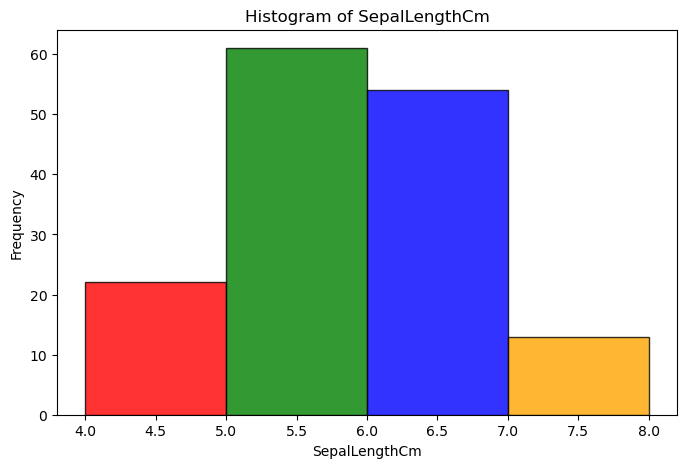

In [5]:
data = df[col]
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    data,
    bins=x_edges if len(x_edges) > 1 else num_bins,  
    color=bar_color,
    edgecolor=edge_color,
    alpha=alpha_value
)

for patch, color in zip(patches, bar_colors):
    patch.set_facecolor(color)

plt.xlabel(col)
plt.ylabel("Frequency")
plt.title(f"Histogram of {col}")
plt.show()

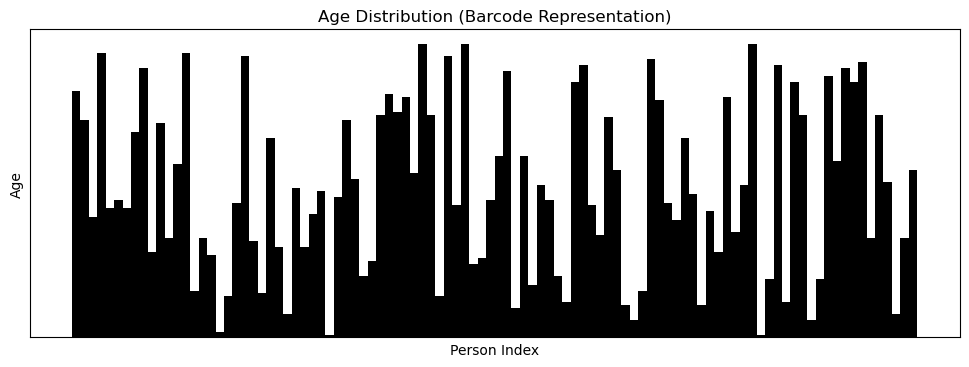

In [6]:
ages = np.random.randint(1, 101, size=100)
plt.figure(figsize=(12, 4))
plt.bar(range(len(ages)), ages, color='black', width=1.0)  
plt.title("Age Distribution (Barcode Representation)")
plt.xlabel("Person Index")
plt.ylabel("Age")
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.show()

We can't make contour as it is not a 2D grid, Z axis

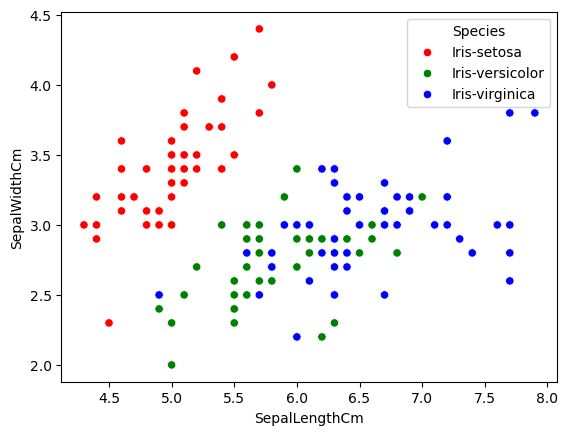

In [7]:
import seaborn as sns

sns.scatterplot(data=df, x="SepalLengthCm", y="SepalWidthCm", hue="Species", palette=['red', 'green', 'blue'])
plt.show()


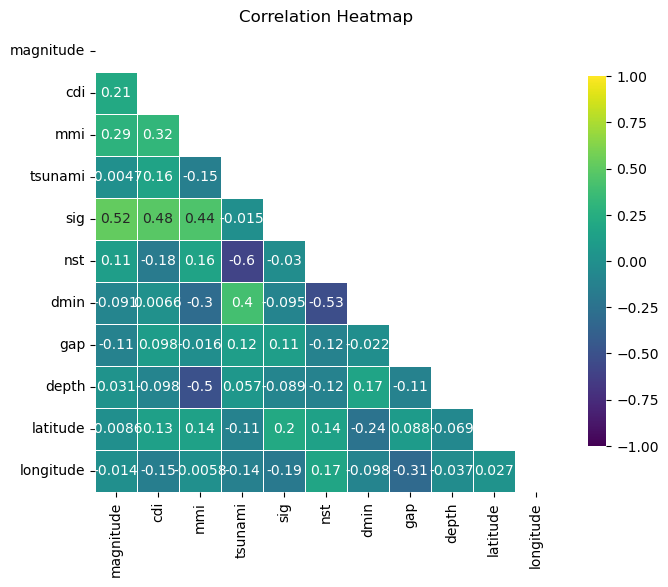

In [15]:
df2 = pd.read_csv("earthquake.csv")

corr = df2.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='viridis',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
import io
from IPython.display import display
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score
from scipy.stats import linregress

In [17]:
diabetes = pd.read_csv('diabetic.csv', na_values='?')
pima = pd.read_csv('pima.csv')

print('diabetic.csv shape:', diabetes.shape)
print('pima.csv shape:', pima.shape)

diabetic.csv shape: (101766, 50)
pima.csv shape: (768, 9)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24716\2175022772.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  diabetes = pd.read_csv('diabetic.csv', na_values='?')


In [18]:
def explore_dataset(df, name, max_cats=3):
    print(f"\n=== {name} head ===")
    display(df.head())

    buf = io.StringIO()
    df.info(buf=buf)
    print(f"\n=== {name} info ===")
    print(buf.getvalue())

    numeric = df.select_dtypes(include=np.number)
    if not numeric.empty:
        print(f"\n=== {name} numeric summary ===")
        display(numeric.describe().transpose())
    else:
        print(f"No numeric columns detected in {name}.")

    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    if categorical_cols:
        print(f"\n=== {name} top categorical counts ===")
        for col in categorical_cols[:max_cats]:
            print(f"\n{col} value counts:")
            print(df[col].value_counts().head())
    else:
        print(f"No categorical columns detected in {name}.")

explore_dataset(diabetes, "Diabetes")
explore_dataset(pima, "Pima Indians")


=== Diabetes head ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



=== Diabetes info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0



=== Diabetes top categorical counts ===

race value counts:
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender value counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age value counts:
age
[70-80)    26068
[60-70)    22483
[50-60)    17256
[80-90)    17197
[40-50)     9685
Name: count, dtype: int64

=== Pima Indians head ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



=== Pima Indians info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


=== Pima Indians numeric summary ===


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


No categorical columns detected in Pima Indians.


In [19]:
diabetes_lin = diabetes[['time_in_hospital', 'num_lab_procedures']].dropna()
if len(diabetes_lin) > 10000:
    diabetes_lin = diabetes_lin.sample(10000, random_state=42)
diabetes_lin_res = linregress(diabetes_lin['num_lab_procedures'], diabetes_lin['time_in_hospital'])

print("Diabetes: time_in_hospital vs num_lab_procedures")
print(f"slope: {diabetes_lin_res.slope:.4f}")
print(f"intercept: {diabetes_lin_res.intercept:.4f}")
print(f"r-value (corr): {diabetes_lin_res.rvalue:.4f}")
print(f"p-value: {diabetes_lin_res.pvalue:.4e}")
print(f"std err: {diabetes_lin_res.stderr:.4f}")

pima_lin = pima[['Glucose', 'BMI']].dropna()
pima_lin_res = linregress(pima_lin['BMI'], pima_lin['Glucose'])

print("\nPima: Glucose vs BMI")
print(f"slope: {pima_lin_res.slope:.4f}")
print(f"intercept: {pima_lin_res.intercept:.4f}")
print(f"r-value (corr): {pima_lin_res.rvalue:.4f}")
print(f"p-value: {pima_lin_res.pvalue:.4e}")
print(f"std err: {pima_lin_res.stderr:.4f}")

Diabetes: time_in_hospital vs num_lab_procedures
slope: 0.0493
intercept: 2.2312
r-value (corr): 0.3246
p-value: 5.2885e-244
std err: 0.0014

Pima: Glucose vs BMI
slope: 0.8965
intercept: 92.2129
r-value (corr): 0.2211
p-value: 5.8914e-10
std err: 0.1429


#### Logistic regression with one predictor

In [20]:
diabetes_log = diabetes[['num_lab_procedures', 'readmitted']].dropna().copy()
diabetes_log['readmit_flag'] = (diabetes_log['readmitted'] != 'NO').astype(int)
if len(diabetes_log) > 20000:
    diabetes_log = diabetes_log.sample(20000, random_state=42)
X_d = diabetes_log[['num_lab_procedures']].astype(float)
y_d = diabetes_log['readmit_flag']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(X_d, y_d, test_size=0.3, random_state=42, stratify=y_d)
log_reg_d = LogisticRegression(solver='liblinear')
log_reg_d.fit(X_d_train, y_d_train)
y_d_pred = log_reg_d.predict(X_d_test)
y_d_prob = log_reg_d.predict_proba(X_d_test)[:, 1]
print("Diabetes logistic regression: readmitted vs num_lab_procedures")
print(f"coef: {log_reg_d.coef_[0][0]:.4f}")
print(f"intercept: {log_reg_d.intercept_[0]:.4f}")
print(f"accuracy: {accuracy_score(y_d_test, y_d_pred):.3f}")
print(f"roc auc: {roc_auc_score(y_d_test, y_d_prob):.3f}")

pima_log = pima[['BMI', 'Outcome']].dropna().copy()
X_p = pima_log[['BMI']]
y_p = pima_log['Outcome']
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.3, random_state=42, stratify=y_p)
log_reg_p = LogisticRegression(solver='liblinear')
log_reg_p.fit(X_p_train, y_p_train)
y_p_pred = log_reg_p.predict(X_p_test)
y_p_prob = log_reg_p.predict_proba(X_p_test)[:, 1]
print("\nPima logistic regression: Outcome vs BMI")
print(f"coef: {log_reg_p.coef_[0][0]:.4f}")
print(f"intercept: {log_reg_p.intercept_[0]:.4f}")
print(f"accuracy: {accuracy_score(y_p_test, y_p_pred):.3f}")
print(f"roc auc: {roc_auc_score(y_p_test, y_p_prob):.3f}")

Diabetes logistic regression: readmitted vs num_lab_procedures
coef: 0.0042
intercept: -0.3336
accuracy: 0.536
roc auc: 0.523

Pima logistic regression: Outcome vs BMI
coef: 0.0728
intercept: -2.9839
accuracy: 0.667
roc auc: 0.699


#### Diabetes: predicting hospital stay with several features

In [21]:
diabetes_features = ['num_lab_procedures', 'num_medications', 'number_inpatient', 'number_outpatient', 'number_diagnoses']
diabetes_multi = diabetes[['time_in_hospital'] + diabetes_features].dropna().copy()
if len(diabetes_multi) > 20000:
    diabetes_multi = diabetes_multi.sample(20000, random_state=42)
X_dm = diabetes_multi[diabetes_features]
y_dm = diabetes_multi['time_in_hospital']
X_dm_train, X_dm_test, y_dm_train, y_dm_test = train_test_split(X_dm, y_dm, test_size=0.3, random_state=42)
lin_reg_dm = LinearRegression()
lin_reg_dm.fit(X_dm_train, y_dm_train)
y_dm_pred = lin_reg_dm.predict(X_dm_test)
print("Diabetes multiple linear regression")
print("features:", diabetes_features)
print(f"intercept: {lin_reg_dm.intercept_:.4f}")
for feature, coef in zip(diabetes_features, lin_reg_dm.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"RMSE: {mean_squared_error(y_dm_test, y_dm_pred, squared=False):.3f}")
print(f"R^2: {r2_score(y_dm_test, y_dm_pred):.3f}")

Diabetes multiple linear regression
features: ['num_lab_procedures', 'num_medications', 'number_inpatient', 'number_outpatient', 'number_diagnoses']
intercept: -0.2474
num_lab_procedures: 0.0319
num_medications: 0.1398
number_inpatient: 0.1283
number_outpatient: -0.1049
number_diagnoses: 0.1270
RMSE: 2.576
R^2: 0.251


c:\Users\lenovo\anaconda3\envs\ai-gpu\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### Pima: predicting glucose with several features

In [22]:
pima_clean = pima.copy()
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_as_missing:
    if col in pima_clean.columns:
        pima_clean[col] = pima_clean[col].replace(0, np.nan)

pima_features = ['Pregnancies', 'BloodPressure', 'BMI', 'Age', 'DiabetesPedigreeFunction']
pima_multi = pima_clean[['Glucose'] + pima_features].dropna().copy()
X_pm = pima_multi[pima_features]
y_pm = pima_multi['Glucose']
X_pm_train, X_pm_test, y_pm_train, y_pm_test = train_test_split(X_pm, y_pm, test_size=0.3, random_state=42)
lin_reg_pm = LinearRegression()
lin_reg_pm.fit(X_pm_train, y_pm_train)
y_pm_pred = lin_reg_pm.predict(X_pm_test)
print("Pima multiple linear regression")
print("features:", pima_features)
print(f"intercept: {lin_reg_pm.intercept_:.4f}")
for feature, coef in zip(pima_features, lin_reg_pm.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"RMSE: {mean_squared_error(y_pm_test, y_pm_pred, squared=False):.3f}")
print(f"R^2: {r2_score(y_pm_test, y_pm_pred):.3f}")

Pima multiple linear regression
features: ['Pregnancies', 'BloodPressure', 'BMI', 'Age', 'DiabetesPedigreeFunction']
intercept: 52.2277
Pregnancies: 0.2243
BloodPressure: 0.2999
BMI: 0.7800
Age: 0.5721
DiabetesPedigreeFunction: 7.0547
RMSE: 30.091
R^2: 0.103


c:\Users\lenovo\anaconda3\envs\ai-gpu\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
